<a href="https://colab.research.google.com/github/priyanka0178885547/DL-lab/blob/main/Week8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

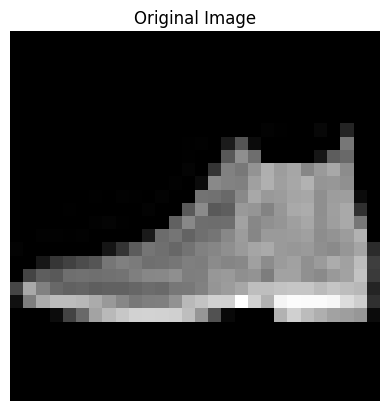

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Layer 1 Shape: (1, 28, 28, 1)


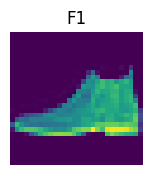

Layer 2 Shape: (1, 28, 28, 32)


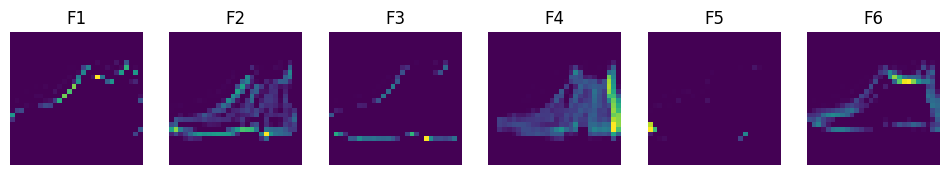

Layer 3 Shape: (1, 14, 14, 32)


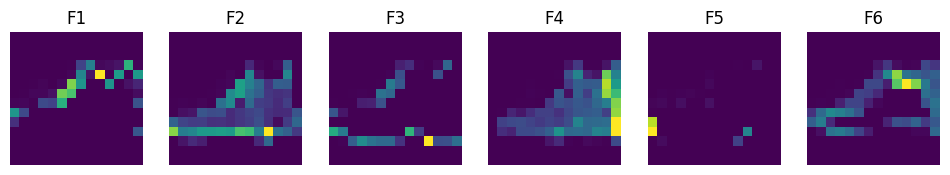

Layer 4 Shape: (1, 14, 14, 64)


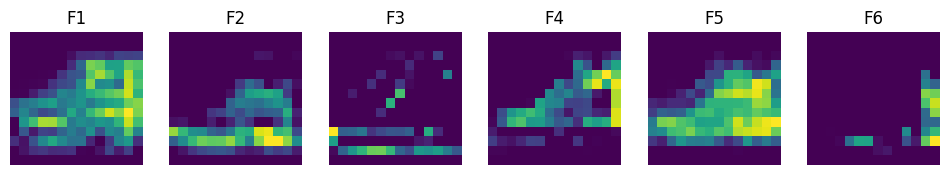

Layer 5 Shape: (1, 7, 7, 64)


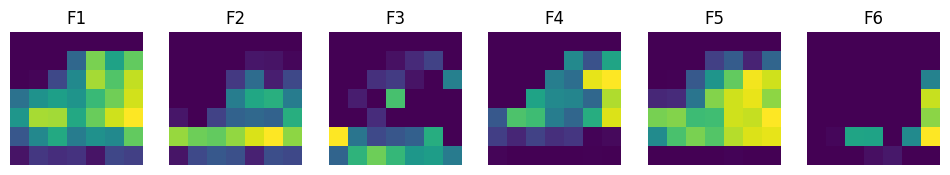

In [ ]:
import keras
from keras import datasets
from keras.models import Model
from keras.layers import Conv2D, MaxPooling2D, Input
import matplotlib.pyplot as plt
import numpy as np

(x_train, y_train), (x_test, y_test) = datasets.fashion_mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

input_layer = Input(shape=(28,28,1))

x = Conv2D(32, (3,3), activation='relu', padding='same')(input_layer)
x = MaxPooling2D((2,2))(x)

x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = MaxPooling2D((2,2))(x)

model = Model(inputs=input_layer, outputs=x)

layer_outputs = [layer.output for layer in model.layers]
feature_model = Model(inputs=model.input, outputs=layer_outputs)

img = x_test[0]
plt.imshow(img.squeeze(), cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.show()

img = np.expand_dims(img, axis=0)

feature_maps = feature_model.predict(img)

for i, fmap in enumerate(feature_maps):
    print("Layer", i+1, "Shape:", fmap.shape)

    num_filters = fmap.shape[-1]

    plt.figure(figsize=(12,5))

    for j in range(min(num_filters, 6)):
        plt.subplot(1,6,j+1)
        plt.imshow(fmap[0, :, :, j], cmap='viridis')
        plt.title(f"F{j+1}")
        plt.axis('off')

    plt.show()

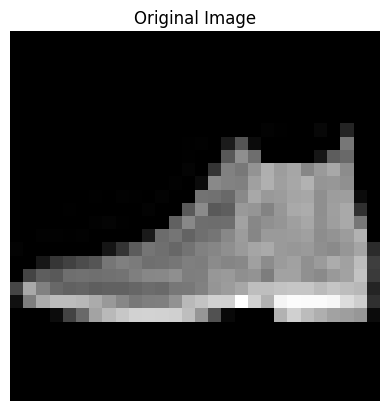

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 538ms/step
Layer 1 Shape: (1, 28, 28, 1)


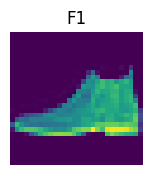

Layer 2 Shape: (1, 28, 28, 64)


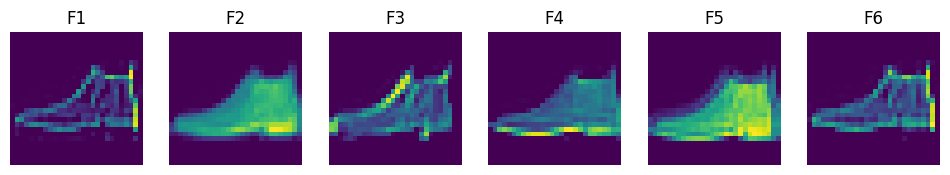

Layer 3 Shape: (1, 14, 14, 64)


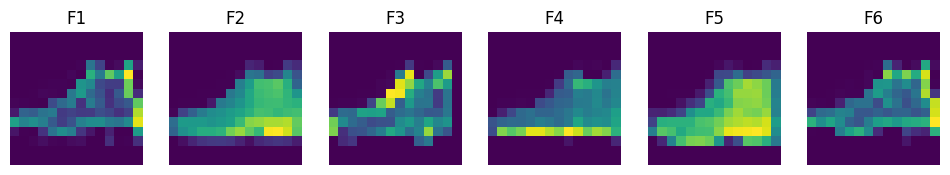

Layer 4 Shape: (1, 14, 14, 128)


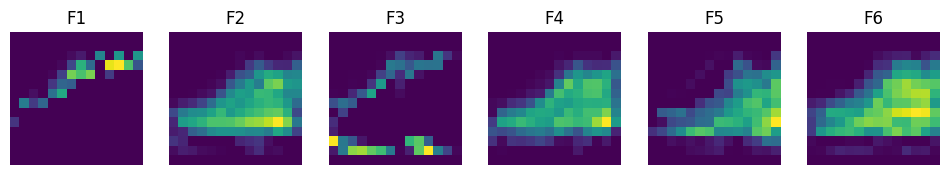

Layer 5 Shape: (1, 7, 7, 128)


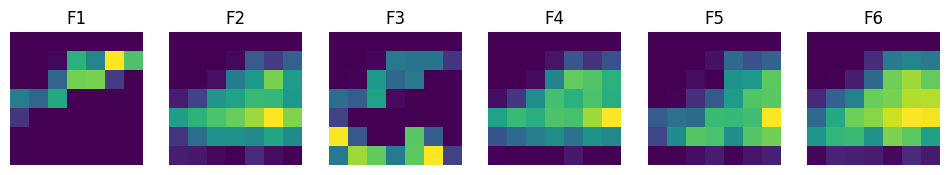

In [ ]:
import keras
from keras import datasets
from keras.models import Model
from keras.layers import Conv2D, MaxPooling2D, Input
import matplotlib.pyplot as plt
import numpy as np

(x_train, y_train), (x_test, y_test) = datasets.fashion_mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

input_layer = Input(shape=(28,28,1))

x = Conv2D(64, (3,3), activation='relu', padding='same')(input_layer)
x = MaxPooling2D((2,2))(x)

x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
x = MaxPooling2D((2,2))(x)

model = Model(inputs=input_layer, outputs=x)

layer_outputs = [layer.output for layer in model.layers]
feature_model = Model(inputs=model.input, outputs=layer_outputs)

img = x_test[0]
plt.imshow(img.squeeze(), cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.show()

img = np.expand_dims(img, axis=0)

feature_maps = feature_model.predict(img)

for i, fmap in enumerate(feature_maps):
    print("Layer", i+1, "Shape:", fmap.shape)

    num_filters = fmap.shape[-1]

    plt.figure(figsize=(12,5))

    for j in range(min(num_filters, 6)):
        plt.subplot(1,6,j+1)
        plt.imshow(fmap[0, :, :, j], cmap='viridis')
        plt.title(f"F{j+1}")
        plt.axis('off')

    plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


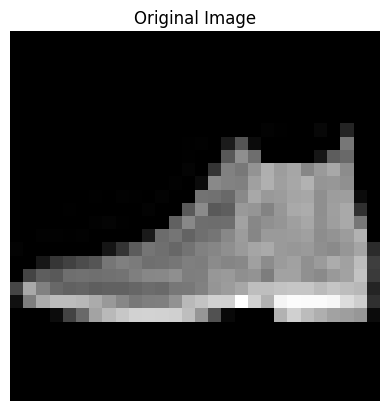

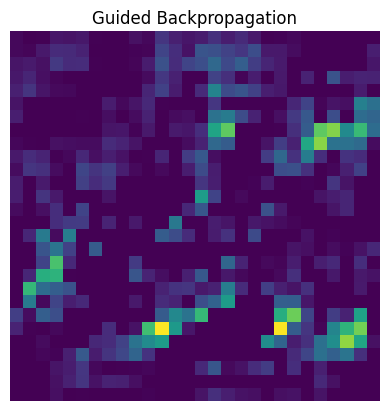

In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

model = keras.models.Sequential([
    keras.layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(28,28,1)),
    keras.layers.MaxPooling2D((2,2)),

    keras.layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    keras.layers.MaxPooling2D((2,2)),

    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.fit(x_train, y_train, epochs=5, batch_size=128, verbose=0)

img = x_test[0]
label = y_test[0]

plt.imshow(img.squeeze(), cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.show()

img = np.expand_dims(img, axis=0)

img_tensor = tf.convert_to_tensor(img)

with tf.GradientTape() as tape:
    tape.watch(img_tensor)
    preds = model(img_tensor)
    class_idx = tf.argmax(preds[0])
    loss = preds[:, class_idx]

grads = tape.gradient(loss, img_tensor)

guided_grads = tf.maximum(grads, 0)
guided_grads = guided_grads.numpy()[0]

guided_grads -= guided_grads.min()
guided_grads /= guided_grads.max()

plt.imshow(guided_grads.squeeze(), cmap='viridis')
plt.title("Guided Backpropagation")
plt.axis('off')
plt.show()

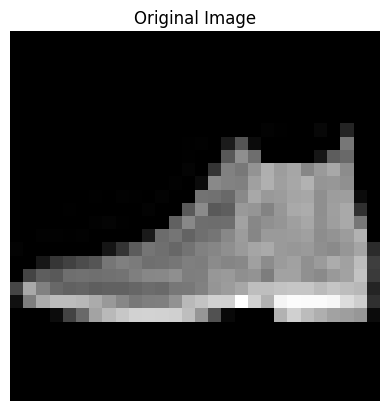

True Label: Ankle boot
Predicted Label: Ankle boot


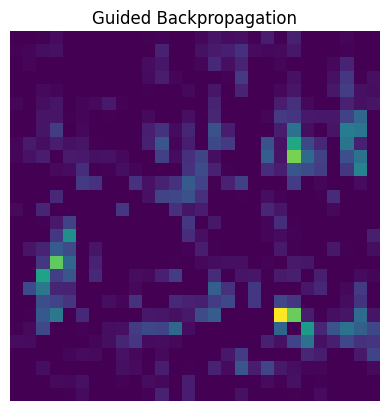

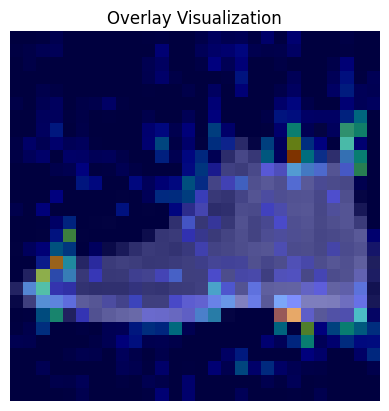

In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

model = keras.models.Sequential([
    keras.layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(28,28,1)),
    keras.layers.MaxPooling2D((2,2)),

    keras.layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    keras.layers.MaxPooling2D((2,2)),

    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.fit(x_train, y_train, epochs=5, batch_size=128, verbose=0)

class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

img = x_test[0]
true_label = y_test[0]

plt.imshow(img.squeeze(), cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.show()

img = np.expand_dims(img, axis=0)
img_tensor = tf.convert_to_tensor(img)

with tf.GradientTape() as tape:
    tape.watch(img_tensor)
    preds = model(img_tensor)
    class_idx = tf.argmax(preds[0])
    loss = preds[:, class_idx]

grads = tape.gradient(loss, img_tensor)

guided_grads = tf.maximum(grads, 0)
guided_grads = guided_grads.numpy()[0]

guided_grads -= guided_grads.min()
guided_grads /= guided_grads.max()

print("True Label:", class_names[true_label])
print("Predicted Label:", class_names[class_idx.numpy()])

plt.imshow(guided_grads.squeeze(), cmap='viridis')
plt.title("Guided Backpropagation")
plt.axis('off')
plt.show()

plt.imshow(img.squeeze(), cmap='gray')
plt.imshow(guided_grads.squeeze(), cmap='jet', alpha=0.5)
plt.title("Overlay Visualization")
plt.axis('off')
plt.show()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


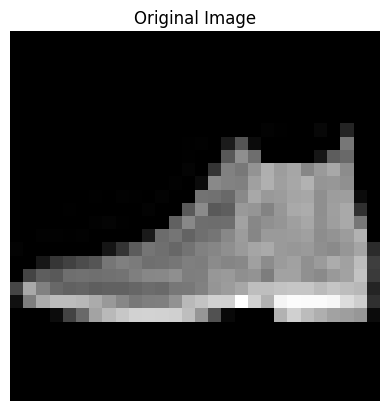

True Label: Ankle boot
Predicted Label: Shirt


/tmp/ipykernel_2604/3251391906.py:70: RuntimeWarning: invalid value encountered in divide
  guided_grads /= guided_grads.max()


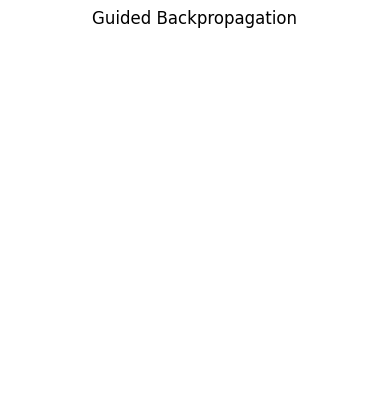

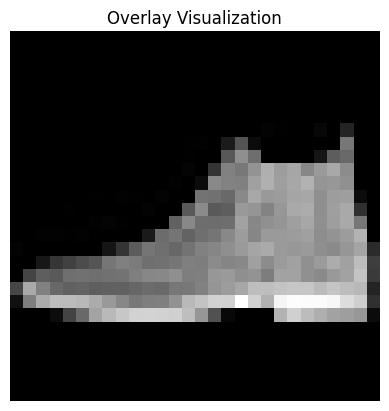

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Model
import numpy as np
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

@tf.custom_gradient
def guided_relu(x):
    def grad(dy):
        return tf.cast(dy > 0, "float32") * tf.cast(x > 0, "float32") * dy
    return tf.nn.relu(x), grad

inputs = keras.Input(shape=(28,28,1))

x = layers.Conv2D(32, (3,3), padding='same')(inputs)
x = layers.Lambda(lambda x: guided_relu(x))(x)
x = layers.MaxPooling2D((2,2))(x)

x = layers.Conv2D(64, (3,3), padding='same')(x)
x = layers.Lambda(lambda x: guided_relu(x))(x)
x = layers.MaxPooling2D((2,2))(x)

x = layers.Flatten()(x)
x = layers.Dense(128)(x)
x = layers.Lambda(lambda x: guided_relu(x))(x)

outputs = layers.Dense(10, activation='softmax')(x)

model = Model(inputs, outputs)

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(x_train, y_train, epochs=5, batch_size=128, verbose=0)

class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

img = x_test[0]
true_label = y_test[0]

plt.imshow(img.squeeze(), cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.show()

img = np.expand_dims(img, axis=0)
img_tensor = tf.convert_to_tensor(img)

with tf.GradientTape() as tape:
    tape.watch(img_tensor)
    preds = model(img_tensor)
    class_idx = tf.argmax(preds[0])
    loss = preds[:, class_idx]

grads = tape.gradient(loss, img_tensor)

guided_grads = grads[0].numpy()
guided_grads -= guided_grads.min()
guided_grads /= guided_grads.max()

print("True Label:", class_names[true_label])
print("Predicted Label:", class_names[class_idx.numpy()])

plt.imshow(guided_grads.squeeze(), cmap='jet')
plt.title("Guided Backpropagation")
plt.axis('off')
plt.show()

plt.imshow(img.squeeze(), cmap='gray')
plt.imshow(guided_grads.squeeze(), cmap='jet', alpha=0.5)
plt.title("Overlay Visualization")
plt.axis('off')
plt.show()

In [1]:
import numpy as np
from tensorflow.keras.datasets import fashion_mnist

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

X_train = X_train.reshape(-1, 784) / 255.0
X_test = X_test.reshape(-1, 784) / 255.0

y_train_onehot = np.zeros((y_train.size, 10))
y_train_onehot[np.arange(y_train.size), y_train] = 1

y_test_onehot = np.zeros((y_test.size, 10))
y_test_onehot[np.arange(y_test.size), y_test] = 1

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

np.random.seed(42)

input_neurons = 784
hidden_neurons = 128
output_neurons = 10

W1 = np.random.randn(input_neurons, hidden_neurons) * 0.01
W2 = np.random.randn(hidden_neurons, output_neurons) * 0.01

lr = 0.1
epochs = 20
batch_size = 64

for epoch in range(epochs):
    for i in range(0, X_train.shape[0], batch_size):
        X_batch = X_train[i:i+batch_size]
        y_batch = y_train_onehot[i:i+batch_size]

        hidden = sigmoid(np.dot(X_batch, W1))
        output = sigmoid(np.dot(hidden, W2))

        error = y_batch - output

        d_output = error * sigmoid_derivative(output)
        d_hidden = d_output.dot(W2.T) * sigmoid_derivative(hidden)

        W2 += hidden.T.dot(d_output) * lr
        W1 += X_batch.T.dot(d_hidden) * lr

hidden_test = sigmoid(np.dot(X_test, W1))
output_test = sigmoid(np.dot(hidden_test, W2))

predictions = np.argmax(output_test, axis=1)
accuracy = np.mean(predictions == y_test)

print("Test Accuracy:", accuracy)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Test Accuracy: 0.1
